In [61]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [62]:
class Data(d2l.DataModule):
    def __init__(
        self,
        batch_size=16,
        T=1000,
        num_train=600,
        tau=4,
    ):
        self.save_hyperparameters()
        
        # [1, 2, 3, ... 1000]
        self.time = torch.arange(
            1,
            T + 1,
            dtype=torch.float32
        )
        
        # sin([0.01, 0.02, ... 10]) + noise(0.2)
        self.x = (
            torch.sin(0.01 * self.time)
            + torch.randn(T) * 0.2
        )
        
        
    def get_dataloader(self, train):
        shifted_sequences = [
            #  [0:996]   [1:997]   [2:998]  [3:999]
            # x[0~995], x[1~996], x[2~997] x[3~998]
            self.x[i : self.T - self.tau + i]
            for i in range(self.tau) # 4
            # 0~995 / 1~996 / 2~997 / 3~998
        ]
        
        #  0   1   2   3  ->  4
        #  1   2   3   4  ->  5
        #         .           .
        #         .           .
        #         .           .
        # 995 996 997 998 -> 999
        self.features = torch.stack(
            shifted_sequences,
            dim=1,
        )
        self.labels = self.x[self.tau:].reshape((-1, 1))
        
        # train: [0: 600]
        # valid: [600:]
        indices = (
            slice(0, self.num_train) # [0 : 600]
            if train 
            else slice(self.num_train, None)
        )
        
        return self.get_tensorloader(
            [self.features, self.labels], 
            train,
            indices,
        )

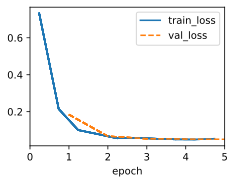

In [63]:
data = Data()

model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)

trainer.fit(
    model,
    data,
)

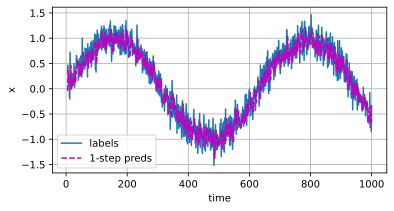

In [64]:
onestep_preds = model(
    data.features,
).detach().numpy()

d2l.plot(
    data.time[data.tau:],
    [
        data.labels,
        onestep_preds,
    ],
    "time",
    "x",
    legend=[
        "labels",
        "1-step preds",
    ],
    figsize=(6, 3),
)

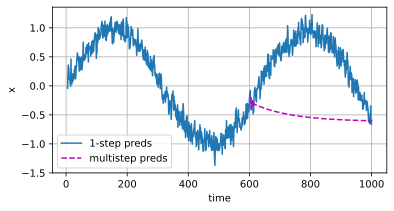

In [ ]:
# shape [1000] with zeros
multistep_preds = torch.zeros(data.T)

# sin([0.01, 0.02, ... 10]) + noise(0.2)
multistep_preds[:] = data.x           


with torch.no_grad():
    
    # 604 ~ 999
    for time_index in range(
        data.num_train + data.tau, # 600 + 4
        data.T,                    # 1000
    ):
        
        # [600: 604]
        # [601: 605]
        #    ...
        # [995: 999]
        input_window = multistep_preds[
            time_index - data.tau : time_index
        ].reshape((1, -1)) # row vector

        prediction = model(input_window)

        multistep_preds[time_index] = prediction.reshape(())

multistep_preds = multistep_preds.numpy()


d2l.plot(
    [
        data.time[data.tau:],
        data.time[data.num_train + data.tau:],
    ],
    [
        onestep_preds,
        multistep_preds[data.num_train + data.tau:],
    ],
    "time",
    "x",
    legend=[
        "1-step preds",
        "multistep preds",
    ],
    figsize=(6, 3),
)

In [66]:
def k_step_pred(k):
    prediction_sequences = []

    prediction_length = (
        data.T
        - data.tau
        - k
        + 1
    )

    for offset in range(data.tau):
        prediction_sequences.append(
            data.x[
                offset : offset + prediction_length
            ]
        )

    with torch.no_grad():
        for step in range(k):
            input_features = torch.stack(
                prediction_sequences[
                    step : step + data.tau
                ],
                dim=1,
            )

            predictions = model(input_features)

            prediction_sequences.append(
                predictions.reshape(-1)
            )

    return prediction_sequences[data.tau:]

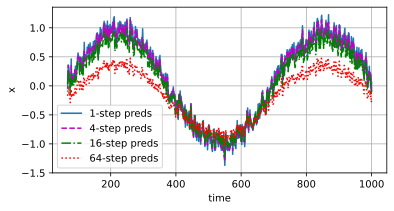

In [67]:
steps = (
    1,
    4,
    16,
    64,
)

predictions = k_step_pred(
    steps[-1],
)

d2l.plot(
    data.time[
        data.tau + steps[-1] - 1 :
    ],
    [
        predictions[k - 1].numpy()
        for k in steps
    ],
    "time",
    "x",
    legend=[
        f"{k}-step preds"
        for k in steps
    ],
    figsize=(6, 3),
)